In [6]:
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import os
import numpy as np

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前运行设备: {device}")

# 确保输出目录存在
output_dir = 'demo_output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

当前运行设备: cpu


In [7]:
# 数据路径配置
# 修改后的相对路径
path_x = 'UCI HAR Dataset/train/X_train.txt'
path_y = 'UCI HAR Dataset/train/y_train.txt'
path_test_x = 'UCI HAR Dataset/test/X_test.txt'
path_test_y = 'UCI HAR Dataset/test/y_test.txt'

# 读取与标准化
train_data = pd.read_csv(path_x, sep=r'\s+', header=None)
train_labels = pd.read_csv(path_y, sep=r'\s+', header=None)
scaler = StandardScaler()
train_data_scaled = scaler.fit_transform(train_data)

# 转换为 Tensor (Batch, Channels=561, Length=1)
train_x_tensor = torch.tensor(train_data_scaled, dtype=torch.float32).unsqueeze(2)
train_y_tensor = torch.tensor(train_labels.values, dtype=torch.long).squeeze() - 1
train_loader = DataLoader(TensorDataset(train_x_tensor, train_y_tensor), batch_size=64, shuffle=True)

#读取与处理测试集 (修复 NameError 的关键)
test_data = pd.read_csv(path_test_x, sep=r'\s+', header=None)
test_labels = pd.read_csv(path_test_y, sep=r'\s+', header=None)
# 使用训练集同样的 scaler 进行转换，确保特征一致性
test_data_scaled = scaler.transform(test_data)

# 转换为测试 Tensor (定义 test_x_tensor 和 test_y_tensor)
test_x_tensor = torch.tensor(test_data_scaled, dtype=torch.float32).unsqueeze(2)
test_y_tensor = torch.tensor(test_labels.values, dtype=torch.long).squeeze() - 1
print("训练数据准备就绪。")

训练数据准备就绪。


In [8]:
class ResNeXtBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, cardinality=32, stride=1):
        super().__init__()
        D = cardinality * 4
        self.conv1 = nn.Conv1d(in_channels, D, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm1d(D)
        self.conv2 = nn.Conv1d(D, D, kernel_size=3, stride=stride, groups=cardinality, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(D)
        self.conv3 = nn.Conv1d(D, out_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += identity
        return self.relu(out)

class ResNeXt1D(nn.Module):
    def __init__(self, in_channels, num_classes, cardinality=32):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, 64, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(64, 64, 3, cardinality)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(64, num_classes)

    def _make_layer(self, in_channels, out_channels, blocks, cardinality):
        layers = [ResNeXtBlock1D(in_channels, out_channels, cardinality)]
        for _ in range(1, blocks):
            layers.append(ResNeXtBlock1D(out_channels, out_channels, cardinality))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

model = ResNeXt1D(in_channels=561, num_classes=6).to(device)
print("模型构建完成。")

模型构建完成。


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print("开始训练...")
for epoch in range(10):
    model.train()
    correct, total = 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    scheduler.step()
    print(f"Epoch [{epoch+1}/10], Acc: {100 * correct / total:.2f}%")

开始训练...
Epoch [1/10], Acc: 87.47%
Epoch [2/10], Acc: 95.44%
Epoch [3/10], Acc: 96.46%
Epoch [4/10], Acc: 97.02%
Epoch [5/10], Acc: 97.65%
Epoch [6/10], Acc: 98.16%
Epoch [7/10], Acc: 98.29%
Epoch [8/10], Acc: 98.69%
Epoch [9/10], Acc: 99.02%
Epoch [10/10], Acc: 98.94%



开始评估测试集并生成结果...
CSV 已保存至: demo_output\imu_action_scores.csv


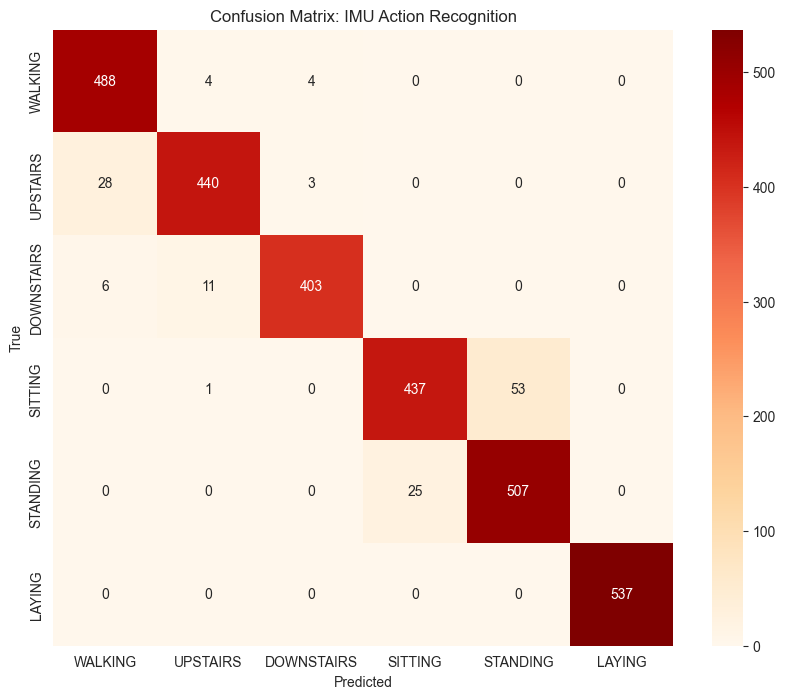

              precision    recall  f1-score   support

     WALKING       0.93      0.98      0.96       496
    UPSTAIRS       0.96      0.93      0.95       471
  DOWNSTAIRS       0.98      0.96      0.97       420
     SITTING       0.95      0.89      0.92       491
    STANDING       0.91      0.95      0.93       532
      LAYING       1.00      1.00      1.00       537

    accuracy                           0.95      2947
   macro avg       0.96      0.95      0.95      2947
weighted avg       0.95      0.95      0.95      2947



In [10]:
# --- 5 & 6 & 7 & 8: 测试、导出与绘图 ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# 1. 数据集定义 (修复 ValueError 的核心)
test_dataset = TensorDataset(test_x_tensor, test_y_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. 最终评估与导出 (修复 pd not defined 的前提是确保顶部运行过 import)
model.eval()
all_actions = []
all_probs = []
all_preds = []
all_labels = []

print("\n开始评估测试集并生成结果...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)

        # 计算概率与预测
        probs = torch.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probs, dim=1)

        # 存入列表用于导出 CSV
        action_mapping = {0: "WALKING", 1: "WALKING_UPSTAIRS", 2: "WALKING_DOWNSTAIRS", 3: "SITTING", 4: "STANDING", 5: "LAYING"}
        all_actions.extend([action_mapping[p.item()] for p in preds])
        all_probs.extend(max_probs.cpu().numpy())

        # 存入列表用于混淆矩阵
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. 导出 CSV
df_output = pd.DataFrame({'action': all_actions, 'prob': all_probs, 'quality_score': [round(p * 0.95 + 0.05, 4) for p in all_probs]})
output_path = os.path.join('demo_output', 'imu_action_scores.csv')
df_output.to_csv(output_path, index=False)
print(f"CSV 已保存至: {output_path}")

# 4. 生成混淆矩阵图表
class_names = ["WALKING", "UPSTAIRS", "DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd', vmax=cm.max(), xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: IMU Action Recognition')
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))